### SARIMA on Monthly Champagne Price Data:

#### 1) Importing Necessary Libaries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmdarima import auto_arima

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

#### 2) Loading Data:

In [2]:
df = pd.read_csv('monthly-champagne-sales.csv',
                index_col= 0,
                parse_dates= True)

In [3]:
df.head()

,Sales
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105 entries, 1964-01-01 to 1972-09-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   105 non-null    int64
dtypes: int64(1)
memory usage: 1.6 KB


In [5]:
df.describe()

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


##### Adding Index Frequency:

In [7]:
df.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='Month', length=105, freq=None)

In [8]:
df.index.freq = 'MS'

In [9]:
df.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='Month', length=105, freq='MS')

##### Visualizing Data:

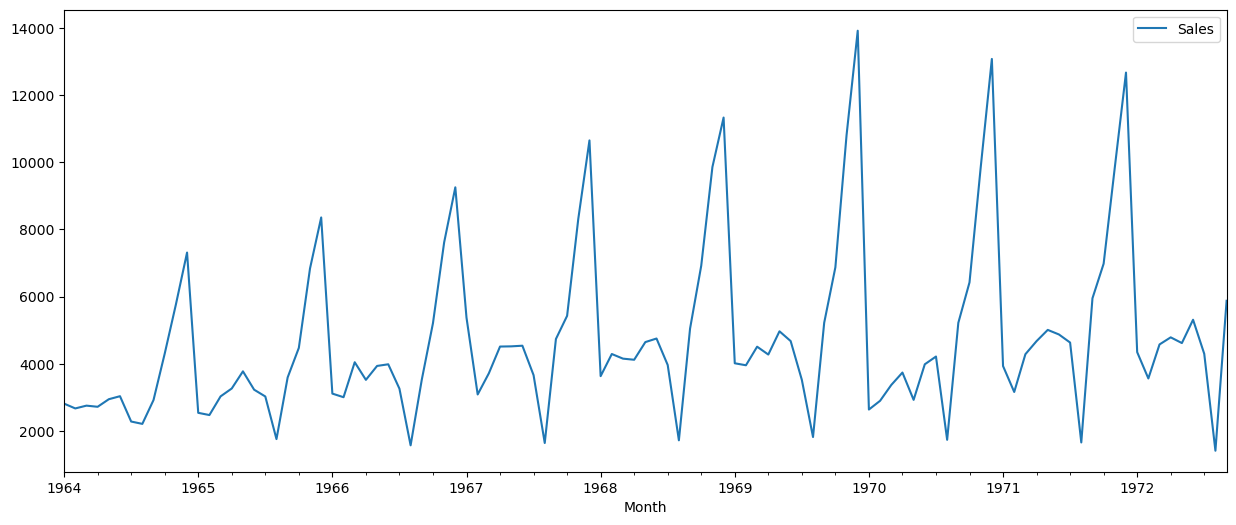

In [10]:
df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) ETS Decomposition:

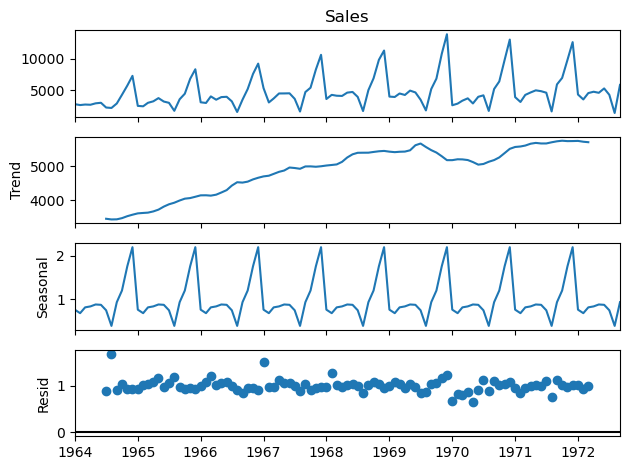

In [11]:
decomp = seasonal_decompose(df['Sales'], model= 'multiplicative')
decomp.plot();

#### 4) Train Test Split:

In [14]:
len(df)

105

In [15]:
train_data = df[:84]
test_data = df[84:]
print(train_data.shape, test_data.shape)

(84, 1) (21, 1)


#### 5) Using AUTO ARIMA to Decide Orders:

In [16]:
grid = auto_arima(y= train_data['Sales'],
                 seasonal= True,
                 m= 12,
                 trace= True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1160.006, Time=0.87 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1183.693, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1173.736, Time=0.10 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1157.042, Time=0.20 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1155.109, Time=0.03 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1157.009, Time=0.17 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1158.348, Time=0.41 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1155.379, Time=0.09 sec
 ARIMA(0,1,2)(0,1,0)[12]             : AIC=1155.138, Time=0.10 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1173.612, Time=0.02 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1155.790, Time=0.12 sec
 ARIMA(0,1,1)(0,1,0)[12] intercept   : AIC=inf, Time=0.06 sec

Best model:  ARIMA(0,1,1)(0,1,0)[12]          
Total fit time: 2.220 seconds


In [17]:
grid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   84
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                -575.554
Date:                             Mon, 22 Dec 2025   AIC                           1155.109
Time:                                     19:10:02   BIC                           1159.634
Sample:                                 01-01-1964   HQIC                          1156.908
                                      - 12-01-1970                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8756      0.060    -14.663      0.000      -0.993      -0.759
sigma2       5.86e+05   7.15e+04      8.195      0.000    4.46e+05    7.26e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                 6.95
Prob(Q):                              0.69   Prob(JB):                         0.03
Heteroskedasticity (H):               2.13   Skew:                             0.01
Prob(H) (two-sided):                  0.07   Kurtosis:                         4.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

`(p, d, q)(P, D, Q)[m]= (0,1,1)(0,1,0)[12]`

#### 6) SARIMA(0,1,1)(0,1,0)[12] Model:

In [18]:
sarima = SARIMAX(endog= train_data['Sales'],
                order= (0, 1, 1),
                seasonal_order= (0, 1, 0, 12))

result = sarima.fit()

In [19]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               Sales   No. Observations:                   84
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                -575.554
Date:                             Mon, 22 Dec 2025   AIC                           1155.109
Time:                                     19:12:07   BIC                           1159.634
Sample:                                 01-01-1964   HQIC                          1156.908
                                      - 12-01-1970                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8756      0.060    -14.663      0.000      -0.993      -0.759
sigma2       5.86e+05   7.15e+04      8.195      0.000    4.46e+05    7.26e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                 6.95
Prob(Q):                              0.69   Prob(JB):                         0.03
Heteroskedasticity (H):               2.13   Skew:                             0.01
Prob(H) (two-sided):                  0.07   Kurtosis:                         4.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##### Predictions on Test Data:

In [20]:
start = len(train_data)
end = len(train_data) + len(test_data) -1

preds = result.predict(start= start, end= end)

In [21]:
preds.head()

1971-01-01    2260.640702
1971-02-01    2520.640702
1971-03-01    2991.640702
1971-04-01    3361.640702
1971-05-01    2548.640702
Freq: MS, Name: predicted_mean, dtype: float64

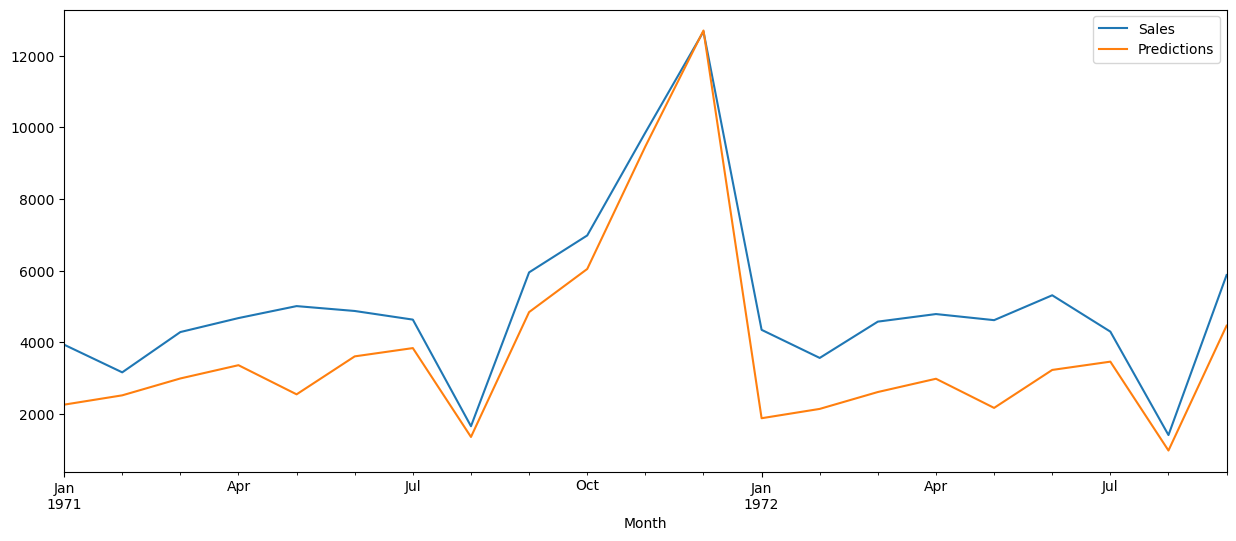

In [22]:
# Plotting Test Data and Predictions:

test_data["Sales"].plot(figsize= (15,6), legend= True)
preds.plot(label= "Predictions", legend= True)
plt.show()

##### Model Evaluation:

In [23]:
np.sqrt(mean_squared_error(test_data['Sales'], preds))

np.float64(1474.8421766193826)

In [24]:
df['Sales'].mean()

np.float64(4761.152380952381)

##### Training on Full Data and Forecasting:

In [25]:
final_sarima = SARIMAX(endog= df['Sales'],
                       order= (0, 1, 1),
                       seasonal_order= (0, 1, 0, 12))

final_result = final_sarima.fit()

In [26]:
final_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               Sales   No. Observations:                  105
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                -743.927
Date:                             Mon, 22 Dec 2025   AIC                           1491.853
Time:                                     19:15:42   BIC                           1496.897
Sample:                                 01-01-1964   HQIC                          1493.889
                                      - 09-01-1972                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8983      0.045    -20.102      0.000      -0.986      -0.811
sigma2      5.727e+05   6.21e+04      9.217      0.000    4.51e+05    6.94e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.95   Jarque-Bera (JB):                 8.66
Prob(Q):                              0.16   Prob(JB):                         0.01
Heteroskedasticity (H):               1.67   Skew:                             0.14
Prob(H) (two-sided):                  0.16   Kurtosis:                         4.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
# Forecasting:

forecast = final_result.predict(start= len(df),
                               end= len(df) + 11)

forecast.head()

1972-10-01     7090.390654
1972-11-01     9960.390654
1972-12-01    12779.390654
1973-01-01     4457.390654
1973-02-01     3673.390654
Freq: MS, Name: predicted_mean, dtype: float64

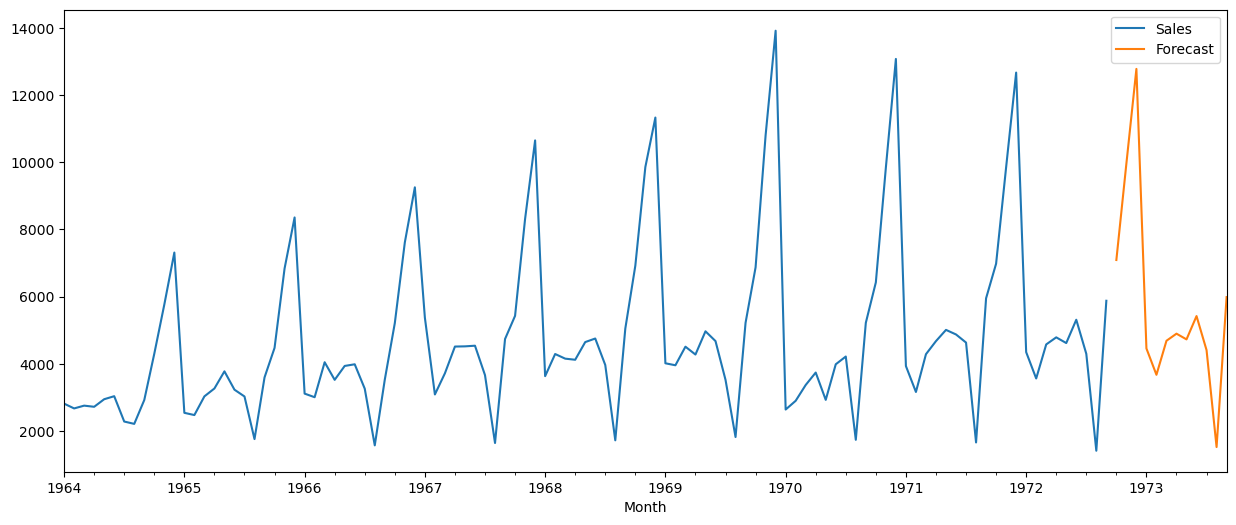

In [29]:
# Plotting Historic and Forecast Data:

df["Sales"].plot(figsize= (15,6), legend= True)
forecast.plot(label= "Forecast", legend= True)
plt.show()